# Grocery Aisles Data Analysis

## Overview
This project performs exploratory data analysis on a grocery aisles dataset.

## Tasks Performed
- Loaded the dataset
- Checked missing values and duplicates
- Generated text-based features
- Analyzed aisle names
- Performed descriptive statistics

## Libraries Used
- Pandas

## Goal
Understand the structure and characteristics of grocery aisle data.

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("aisles.csv")

In [4]:
df.head()

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


In [5]:
df.describe()

,aisle_id
count,134.000000
mean,67.500000
std,38.826537
min,1.000000
25%,34.250000
50%,67.500000
75%,100.750000
max,134.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB


In [6]:
df.isnull().sum()

aisle_id    0
aisle       0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [12]:
df["word_count"] = df["aisle"].apply(lambda x: len(str(x).split()))
df["char_count"] = df["aisle"].str.len()


In [13]:
from collections import Counter

all_words = " ".join(df["aisle"].str.lower()).split()
stop_words = {"and", "with", "in", "of", "for", "to", "or", "an"}
filtered_words = [w for w in all_words if w not in stop_words]

top_words = Counter(filtered_words).most_common(10)
df_words = pd.DataFrame(top_words, columns=["Word", "Count"]).sort_values(
    by="Count"
)
print("Features created successfully!")

Features created successfully!


In [11]:
df.head()

,aisle_id,aisle,word_count,char_count
0,1,prepared soups salads,3,21
1,2,specialty cheeses,2,17
2,3,energy granola bars,3,19
3,4,instant foods,2,13
4,5,marinades meat preparation,3,26


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns


C:\Users\harsh\AppData\Local\Temp\ipykernel_2960\2126592377.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Count", y="Word", data=df_words, palette="viridis")


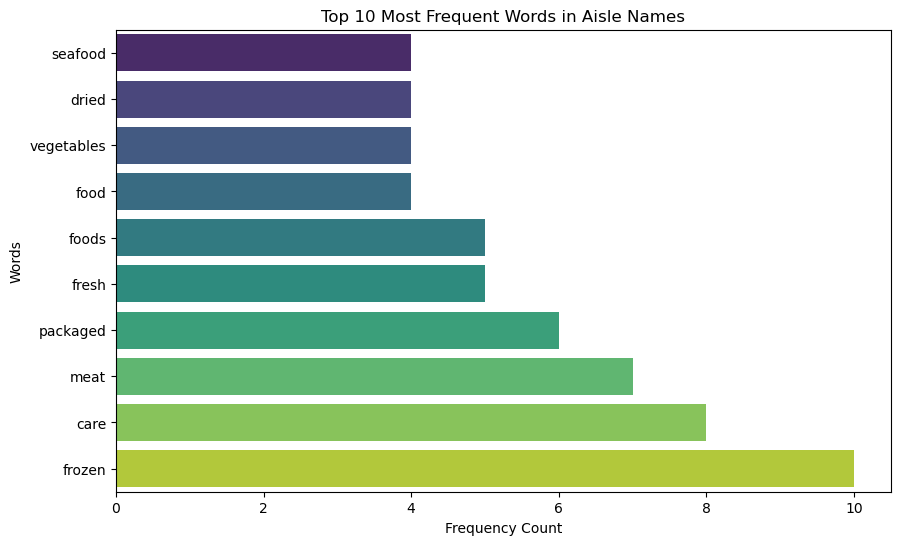

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(x="Count", y="Word", data=df_words, palette="viridis")
plt.title("Top 10 Most Frequent Words in Aisle Names")
plt.xlabel("Frequency Count")
plt.ylabel("Words")
plt.show()

C:\Users\harsh\AppData\Local\Temp\ipykernel_2960\4176373955.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="word_count", palette="muted", edgecolor="black")


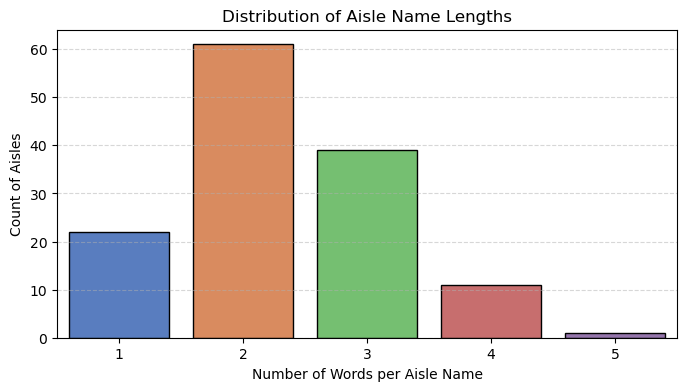

In [16]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x="word_count", palette="muted", edgecolor="black")
plt.xlabel("Number of Words per Aisle Name")
plt.ylabel("Count of Aisles")
plt.title("Distribution of Aisle Name Lengths")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
features = ["word_count", "char_count"]


In [19]:
X = df[features]

In [20]:
scaler = StandardScaler()

In [21]:
X_scaled = scaler.fit_transform(X)

In [22]:
df_scaled = pd.DataFrame(X_scaled, columns=features)

In [23]:
df_scaled.head()

,word_count,char_count
0,0.791458,0.954325
1,-0.361318,0.305190
2,0.791458,0.629758
3,-0.361318,-0.343945
4,0.791458,1.765744


In [24]:
from sklearn.cluster import KMeans

In [25]:
wcss = []
cluster_range = range(1, 11)

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

C:\ano\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ano\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ano\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ano\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can a

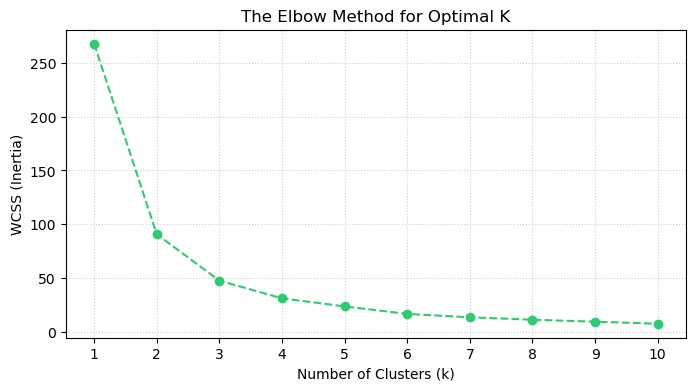

In [26]:
plt.figure(figsize=(8, 4))
plt.plot(cluster_range, wcss, marker="o", linestyle="--", color="#2ecc71")
plt.title("The Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS (Inertia)")
plt.xticks(cluster_range)
plt.grid(True, linestyle=":", alpha=0.6)
plt.show()

In [27]:
final_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df["cluster"] = final_kmeans.fit_predict(X_scaled)

print("CLUSTERING COMPLETED")
print(df["cluster"].value_counts().sort_index())

for c in range(3):
    print(f"\nCluster {c} Sample Aisles")
    print(df[df["cluster"] == c]["aisle"].head(5).tolist())

CLUSTERING COMPLETED
cluster
0    47
1    65
2    22
Name: count, dtype: int64

--- Cluster 0 Sample Aisles ---
['prepared soups salads', 'energy granola bars', 'marinades meat preparation', 'cold flu allergy', 'tofu meat alternatives']

--- Cluster 1 Sample Aisles ---
['specialty cheeses', 'instant foods', 'packaged meat', 'bakery desserts', 'pasta sauce']

--- Cluster 2 Sample Aisles ---
['other', 'soap', 'coffee', 'refrigerated', 'butter']


C:\ano\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


<Axes: xlabel='char_count', ylabel='word_count'>

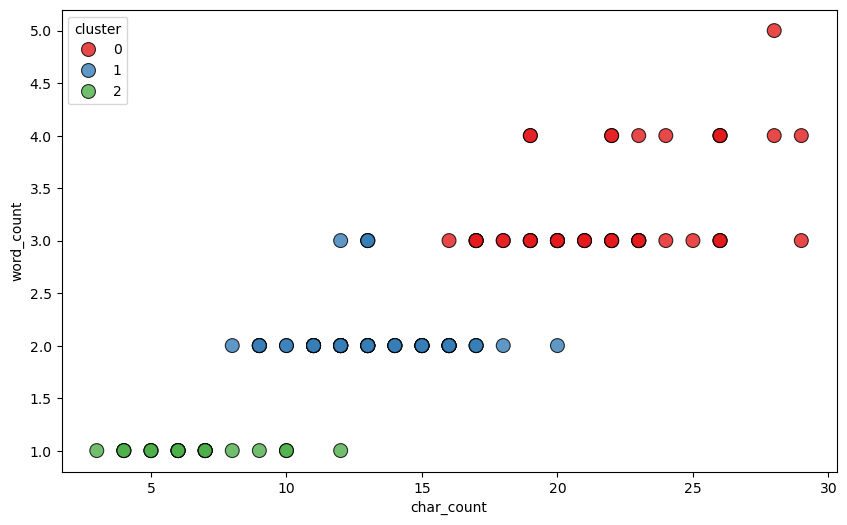

In [28]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x="char_count",
    y="word_count",
    hue="cluster",
    palette="Set1",
    s=100,
    edgecolor="black",
    alpha=0.8,
)

In [29]:
final_export = df[["aisle_id", "aisle", "word_count", "char_count", "cluster"]]

In [30]:
output_filename = "segmented_grocery_aisles.csv"
final_export.to_csv(output_filename, index=False)

In [31]:
print(f"Successfully exported final segmented dataset to: '{output_filename}'")
print("You can now download this file directly from your Jupyter directory!")

Successfully exported final segmented dataset to: 'segmented_grocery_aisles.csv'
You can now download this file directly from your Jupyter directory!


In [33]:
cluster_profile = (
    df.groupby("cluster")[["word_count", "char_count"]]
    .agg(["mean", "min", "max", "count"])
    .round(2)
)

print("CLUSTER PROFILE ANALYSIS")
cluster_profile

CLUSTER PROFILE ANALYSIS


word_count               char_count              
              mean min max count       mean min max count
cluster                                                  
0             3.28   3   5    47      21.91  16  29    47
1             2.06   2   3    65      13.11   8  20    65
2             1.00   1   1    22       6.55   3  12    22

C:\Users\harsh\AppData\Local\Temp\ipykernel_2960\2303538516.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


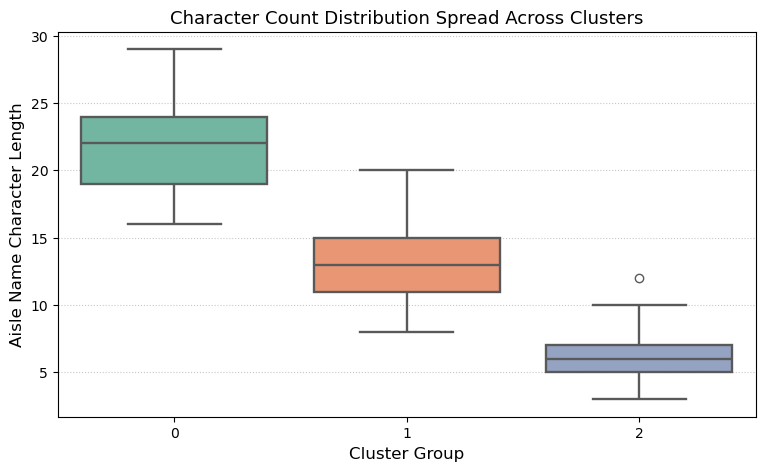

In [38]:
plt.figure(figsize=(9, 5))
sns.boxplot(
    data=df, x="cluster", y="char_count", palette="Set2", linewidth=1.7
)

plt.title(
    "Character Count Distribution Spread Across Clusters",
    fontsize=13,
    fontweight="light",
)
plt.xlabel("Cluster Group", fontsize=12)
plt.ylabel("Aisle Name Character Length", fontsize=12)
plt.grid(axis="y", linestyle=":", alpha=0.7)

plt.show()